# Backtest analysis — cleaned

This version keeps the working analysis path and removes duplicate/experimental cells. It loads actual meter data, spot prices, and the predicted MILP plan; derives 15-minute actual/no-battery/MILP costs; then produces daily comparisons and plots.


## Configuration and imports

Adjust the database/table names or battery constants here if needed.

In [7]:
import ast
import json
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = "FVEDB.db"
ACTUAL_TABLE = "MqttData"
SPOT_TABLE = "SpotData"
MILP_TABLE = "PredictedControlData"

BATTERY_CAPACITY_KWH = 14.4
BATTERY_MIN_PERCENT = 20.0
BATTERY_MAX_PERCENT = 95.0
BATTERY_MAX_CHARGE_KW = 7.5
BATTERY_MAX_DISCHARGE_KW = 7.5


# Daily data-quality filtering.
# A day is considered bad when more than this share of expected 15-minute
# intervals has insufficient accepted counter coverage.
MAX_MISSING_COUNTER_SHARE = 0.10
MIN_INTERVAL_COUNTER_COVERAGE_SHARE = 0.95
EXPECTED_INTERVALS_PER_DAY = 96


## Data loading helpers

In [8]:
def _force_numeric(series: pd.Series) -> pd.Series:
    """Parse numbers that may use either comma or period as the decimal separator."""
    return (
        series.astype(str)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )


def _parse_list_cell(value):
    """Parse JSON/Python-list strings from the MILP table."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, list):
        return value

    text = str(value).strip()
    if not text:
        return []

    try:
        return json.loads(text)
    except Exception:
        return ast.literal_eval(text)


def load_actual_data(db_path: str = DB_PATH, table_name: str = ACTUAL_TABLE) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query(
        f"""
        SELECT
            DateTime,
            SoC,
            P_BAT,
            P_PV,
            BUY_T,
            SELL_T,
            fromBAT_T AS FromBAT_T,
            toBAT_T AS ToBAT_T
        FROM {table_name}
        ORDER BY DateTime
        """,
        conn,
    )
    conn.close()

    df["DateTime"] = pd.to_datetime(df["DateTime"])
    df = df.set_index("DateTime").sort_index()

    for col in ["SoC", "P_BAT", "P_PV", "BUY_T", "SELL_T", "FromBAT_T", "ToBAT_T"]:
        if col in df.columns:
            df[col] = _force_numeric(df[col])

    return df


def load_spot_data(db_path: str = DB_PATH, table_name: str = SPOT_TABLE) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query(
        f"""
        SELECT
            DateTime,
            Value
        FROM {table_name}
        ORDER BY DateTime
        """,
        conn,
    )
    conn.close()

    df["DateTime"] = pd.to_datetime(df["DateTime"])
    df = df.set_index("DateTime").sort_index()
    df = df.rename(columns={"Value": "spot_price"})
    df["spot_price"] = _force_numeric(df["spot_price"])

    return df


def load_milp_daily_plan(db_path: str = DB_PATH, table_name: str = MILP_TABLE) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query(
        f"""
        SELECT
            TimeStamp,
            ChargeTimes,
            DischargeTimes,
            ChargeToCapacities,
            PriceSum
        FROM {table_name}
        ORDER BY TimeStamp
        """,
        conn,
    )
    conn.close()

    df["TimeStamp"] = pd.to_datetime(df["TimeStamp"])
    df["ChargeTimes"] = df["ChargeTimes"].apply(_parse_list_cell)
    df["DischargeTimes"] = df["DischargeTimes"].apply(_parse_list_cell)
    df["ChargeToCapacities"] = df["ChargeToCapacities"].apply(_parse_list_cell)

    if "PriceSum" in df.columns:
        df["PriceSum"] = _force_numeric(df["PriceSum"])
        df = df.rename(columns={"PriceSum": "predicted_cost"})

    return df


## Cost and MILP replay helpers

In [9]:
def compute_interval_energies_from_counters(
    df_actual: pd.DataFrame,
    df_spot: pd.DataFrame,
    max_interval_minutes: int = 60,
) -> pd.DataFrame:
    """Prorate cumulative energy-counter deltas into 15-minute spot-price intervals."""
    df = df_actual.copy().sort_index()
    spot = df_spot.copy().sort_index()

    for col in ["BUY_T", "SELL_T", "ToBAT_T", "FromBAT_T"]:
        df[col] = _force_numeric(df[col])

    out = spot.copy()
    out["buy_kwh"] = 0.0
    out["sell_kwh"] = 0.0
    out["to_bat_kwh"] = 0.0
    out["from_bat_kwh"] = 0.0

    # Track how much of each 15-minute bin is covered by valid counter deltas.
    # This is used later to identify good/bad days before calculating averages.
    out["counter_covered_seconds"] = 0.0

    prev_time = None
    prev_vals = None

    for ts, row in df.iterrows():
        vals = row[["BUY_T", "SELL_T", "ToBAT_T", "FromBAT_T"]]

        if prev_time is None:
            prev_time = ts
            prev_vals = vals
            continue

        if vals.isna().any() or prev_vals.isna().any():
            prev_time = ts
            prev_vals = vals
            continue

        interval_min = (ts - prev_time).total_seconds() / 60.0
        if interval_min <= 0 or interval_min > max_interval_minutes:
            prev_time = ts
            prev_vals = vals
            continue

        deltas = vals - prev_vals
        if (deltas < 0).any():
            prev_time = ts
            prev_vals = vals
            continue

        interval_start = prev_time
        interval_end = ts
        total_seconds = (interval_end - interval_start).total_seconds()

        bin_start = interval_start.floor("15min")
        bin_end = interval_end.floor("15min")
        bins = pd.date_range(bin_start, bin_end, freq="15min")

        for bin_time in bins:
            bin_start_time = bin_time
            bin_end_time = bin_time + pd.Timedelta(minutes=15)

            overlap_start = max(interval_start, bin_start_time)
            overlap_end = min(interval_end, bin_end_time)
            overlap_seconds = (overlap_end - overlap_start).total_seconds()

            if overlap_seconds <= 0:
                continue

            weight = overlap_seconds / total_seconds

            if bin_time in out.index:
                out.at[bin_time, "buy_kwh"] += deltas["BUY_T"] * weight
                out.at[bin_time, "sell_kwh"] += deltas["SELL_T"] * weight
                out.at[bin_time, "to_bat_kwh"] += deltas["ToBAT_T"] * weight
                out.at[bin_time, "from_bat_kwh"] += deltas["FromBAT_T"] * weight
                out.at[bin_time, "counter_covered_seconds"] += overlap_seconds

        prev_time = ts
        prev_vals = vals

    out["counter_coverage_share"] = (out["counter_covered_seconds"] / (15 * 60)).clip(upper=1.0)
    out["has_counter_coverage"] = out["counter_coverage_share"] >= MIN_INTERVAL_COUNTER_COVERAGE_SHARE

    out["actual_grid_net_kwh"] = out["buy_kwh"] - out["sell_kwh"]
    out["actual_cost"] = out["actual_grid_net_kwh"] * out["spot_price"]
    return out



def build_daily_data_quality(
    counter_15: pd.DataFrame,
    expected_intervals_per_day: int = EXPECTED_INTERVALS_PER_DAY,
) -> pd.DataFrame:
    """Summarize counter coverage by day.

    A 15-minute bin is counted as covered only when enough of that bin was
    reconstructed from valid cumulative-counter deltas.
    """
    df = counter_15.copy()

    daily_quality = pd.DataFrame({
        "spot_bins": df["spot_price"].resample("1D").count(),
        "covered_counter_bins": df["has_counter_coverage"].resample("1D").sum(),
        "covered_counter_seconds": df["counter_covered_seconds"].resample("1D").sum(),
    })

    daily_quality["expected_bins"] = expected_intervals_per_day
    daily_quality["missing_spot_bins"] = (
        daily_quality["expected_bins"] - daily_quality["spot_bins"]
    ).clip(lower=0)

    daily_quality["missing_counter_bins"] = (
        daily_quality["expected_bins"] - daily_quality["covered_counter_bins"]
    ).clip(lower=0)

    daily_quality["spot_missing_share"] = (
        daily_quality["missing_spot_bins"] / daily_quality["expected_bins"]
    )

    daily_quality["counter_missing_share"] = (
        daily_quality["missing_counter_bins"] / daily_quality["expected_bins"]
    )

    daily_quality["counter_coverage_share"] = (
        daily_quality["covered_counter_seconds"] /
        (daily_quality["expected_bins"] * 15 * 60)
    ).clip(upper=1.0)

    return daily_quality


def flag_bad_days(
    daily_quality: pd.DataFrame,
    max_missing_counter_share: float = MAX_MISSING_COUNTER_SHARE,
) -> pd.DataFrame:
    """Flag days with too much missing spot or counter coverage."""
    dq = daily_quality.copy()

    dq["bad_day"] = (
        (dq["spot_missing_share"] > max_missing_counter_share) |
        (dq["counter_missing_share"] > max_missing_counter_share)
    )

    dq["good_day"] = ~dq["bad_day"]
    return dq


def compute_no_battery_cost_from_counters(counter_15: pd.DataFrame) -> pd.DataFrame:
    """Remove actual battery charge/discharge energy from the observed grid exchange."""
    out = counter_15.copy()

    out["nobatt_grid_net_kwh"] = (
        out["actual_grid_net_kwh"]
        - out["to_bat_kwh"]
        + out["from_bat_kwh"]
    )

    out["nobatt_buy_kwh"] = out["nobatt_grid_net_kwh"].clip(lower=0.0)
    out["nobatt_sell_kwh"] = (-out["nobatt_grid_net_kwh"]).clip(lower=0.0)
    out["nobatt_cost"] = out["nobatt_grid_net_kwh"] * out["spot_price"]

    return out


def expand_milp_daily_plan_to_mode_changes(milp_daily: pd.DataFrame) -> pd.DataFrame:
    """Convert daily charge/discharge timestamps into mode-change events."""
    rows = []

    for _, day in milp_daily.iterrows():
        charge_times = sorted(pd.to_datetime(day["ChargeTimes"]))
        discharge_times = sorted(pd.to_datetime(day["DischargeTimes"]))
        targets = [float(x) for x in day["ChargeToCapacities"]]

        charge_sessions = []
        if charge_times:
            current = [charge_times[0]]
            for timestamp in charge_times[1:]:
                if (timestamp - current[-1]) == pd.Timedelta(minutes=15):
                    current.append(timestamp)
                else:
                    charge_sessions.append(current)
                    current = [timestamp]
            charge_sessions.append(current)

        discharge_sessions = []
        if discharge_times:
            current = [discharge_times[0]]
            for timestamp in discharge_times[1:]:
                if (timestamp - current[-1]) == pd.Timedelta(minutes=15):
                    current.append(timestamp)
                else:
                    discharge_sessions.append(current)
                    current = [timestamp]
            discharge_sessions.append(current)

        for idx, session in enumerate(charge_sessions):
            if len(targets) == 0:
                target = None
            elif idx < len(targets):
                target = targets[idx]
            else:
                target = targets[-1]

            rows.append({
                "DateTime": session[0],
                "mode": "charge",
                "target_soc_percent": target,
            })

        for session in discharge_sessions:
            rows.append({
                "DateTime": session[0],
                "mode": "discharge",
                "target_soc_percent": None,
            })

    out = pd.DataFrame(rows)
    out["DateTime"] = pd.to_datetime(out["DateTime"])
    return out.sort_values("DateTime").set_index("DateTime")


def replay_milp_state_machine_without_phome(
    counter_15: pd.DataFrame,
    milp_mode_changes: pd.DataFrame,
    actual_raw: pd.DataFrame,
    capacity_kwh: float = BATTERY_CAPACITY_KWH,
    min_percent: float = BATTERY_MIN_PERCENT,
    max_percent: float = BATTERY_MAX_PERCENT,
    max_charge_kw: float = BATTERY_MAX_CHARGE_KW,
    max_discharge_kw: float = BATTERY_MAX_DISCHARGE_KW,
) -> pd.DataFrame:
    """Replay MILP mode changes against the no-battery residual load."""
    raw_soc = actual_raw.copy()
    raw_soc["SoC"] = _force_numeric(raw_soc["SoC"])
    daily_initial_soc = raw_soc["SoC"].resample("1D").first()

    all_rows = []
    dt = 0.25

    for day_start, initial_soc_percent in daily_initial_soc.dropna().items():
        day_end = day_start + pd.Timedelta(days=1)

        base_day = counter_15.loc[(counter_15.index >= day_start) & (counter_15.index < day_end)].copy()
        mode_day = milp_mode_changes.loc[
            (milp_mode_changes.index >= day_start) &
            (milp_mode_changes.index < day_end)
        ]

        if base_day.empty:
            continue

        merged = base_day.join(mode_day[["mode", "target_soc_percent"]], how="left")

        soc_kwh = capacity_kwh * float(initial_soc_percent) / 100.0
        min_kwh = capacity_kwh * min_percent / 100.0
        max_kwh = capacity_kwh * max_percent / 100.0

        current_mode = None
        current_target_soc_kwh = None
        rows = []

        for ts, row in merged.iterrows():
            price = float(row["spot_price"])

            nobatt_grid_net_kwh = (
                float(row["actual_grid_net_kwh"])
                - float(row["to_bat_kwh"])
                + float(row["from_bat_kwh"])
            )
            nobatt_grid_net_kw = nobatt_grid_net_kwh / dt

            surplus_kw = max(-nobatt_grid_net_kw, 0.0)
            deficit_kw = max(nobatt_grid_net_kw, 0.0)

            if pd.notna(row.get("mode")):
                current_mode = row["mode"]
                if current_mode == "charge" and pd.notna(row.get("target_soc_percent")):
                    current_target_soc_kwh = capacity_kwh * float(row["target_soc_percent"]) / 100.0
                    current_target_soc_kwh = min(max(current_target_soc_kwh, min_kwh), max_kwh)
                else:
                    current_target_soc_kwh = None

            free_room_kw = max((max_kwh - soc_kwh) / dt, 0.0)
            available_discharge_kw = max((soc_kwh - min_kwh) / dt, 0.0)

            # PV surplus always charges the battery first.
            executed_pv_charge = min(surplus_kw, max_charge_kw, free_room_kw)

            executed_grid_charge = 0.0
            executed_discharge = 0.0

            if current_mode == "charge":
                if current_target_soc_kwh is not None and soc_kwh < current_target_soc_kwh:
                    remaining_to_target_kw = max((current_target_soc_kwh - soc_kwh) / dt, 0.0)
                    remaining_charge_headroom_kw = max(max_charge_kw - executed_pv_charge, 0.0)
                    remaining_free_room_kw = max((max_kwh - soc_kwh) / dt - executed_pv_charge, 0.0)

                    executed_grid_charge = min(
                        remaining_to_target_kw,
                        remaining_charge_headroom_kw,
                        remaining_free_room_kw,
                    )
                elif current_target_soc_kwh is not None and soc_kwh >= current_target_soc_kwh:
                    current_mode = None

            elif current_mode == "discharge":
                executed_discharge = min(
                    max_discharge_kw,
                    deficit_kw,
                    available_discharge_kw,
                )

                if soc_kwh <= min_kwh + 1e-9:
                    current_mode = None

            grid_sell_kw = max(surplus_kw - executed_pv_charge, 0.0)
            grid_buy_kw = max(deficit_kw - executed_discharge + executed_grid_charge, 0.0)

            grid_buy_kwh = grid_buy_kw * dt
            grid_sell_kwh = grid_sell_kw * dt

            soc_kwh = soc_kwh + (executed_pv_charge + executed_grid_charge - executed_discharge) * dt
            soc_kwh = min(max(soc_kwh, min_kwh), max_kwh)

            rows.append({
                "DateTime": ts,
                "milp_mode": current_mode,
                "nobatt_grid_net_kwh": nobatt_grid_net_kwh,
                "milp_grid_buy_kwh": grid_buy_kwh,
                "milp_grid_sell_kwh": grid_sell_kwh,
                "milp_exec_pv_charge_kw": executed_pv_charge,
                "milp_exec_grid_charge_kw": executed_grid_charge,
                "milp_exec_discharge_kw": executed_discharge,
                "milp_soc_percent": soc_kwh * 100.0 / capacity_kwh,
                "milp_cost": (grid_buy_kwh - grid_sell_kwh) * price,
            })

        all_rows.extend(rows)

    return pd.DataFrame(all_rows).set_index("DateTime").sort_index()


def compute_milp_cost_from_counters_and_plan(
    counter_15: pd.DataFrame,
    milp_15: pd.DataFrame,
) -> pd.DataFrame:
    """Combine the replayed MILP actions with actual counter-derived energy."""
    out = counter_15.copy().join(
        milp_15[[
            "milp_exec_pv_charge_kw",
            "milp_exec_grid_charge_kw",
            "milp_exec_discharge_kw",
            "milp_soc_percent",
        ]],
        how="left",
    )

    out["milp_exec_pv_charge_kw"] = out["milp_exec_pv_charge_kw"].fillna(0.0)
    out["milp_exec_grid_charge_kw"] = out["milp_exec_grid_charge_kw"].fillna(0.0)
    out["milp_exec_discharge_kw"] = out["milp_exec_discharge_kw"].fillna(0.0)

    dt = 0.25
    out["milp_charge_kwh"] = (
        out["milp_exec_pv_charge_kw"] + out["milp_exec_grid_charge_kw"]
    ) * dt
    out["milp_discharge_kwh"] = out["milp_exec_discharge_kw"] * dt

    out["milp_grid_net_kwh"] = (
        out["actual_grid_net_kwh"]
        - out["to_bat_kwh"]
        + out["from_bat_kwh"]
        + out["milp_charge_kwh"]
        - out["milp_discharge_kwh"]
    )

    out["milp_buy_kwh"] = out["milp_grid_net_kwh"].clip(lower=0.0)
    out["milp_sell_kwh"] = (-out["milp_grid_net_kwh"]).clip(lower=0.0)
    out["milp_cost"] = out["milp_grid_net_kwh"] * out["spot_price"]

    return out


## Run the backtest

In [52]:
actual_raw = load_actual_data()
spot = load_spot_data()
milp_daily = load_milp_daily_plan()

counter_15 = compute_interval_energies_from_counters(actual_raw, spot)

daily_data_quality = build_daily_data_quality(counter_15)
daily_quality = flag_bad_days(daily_data_quality)

actual_cost_15 = counter_15.copy()
nobatt_15 = compute_no_battery_cost_from_counters(counter_15)

milp_mode_changes = expand_milp_daily_plan_to_mode_changes(milp_daily)
milp_15 = replay_milp_state_machine_without_phome(
    counter_15=counter_15,
    milp_mode_changes=milp_mode_changes,
    actual_raw=actual_raw,
)
milp_counter_15 = compute_milp_cost_from_counters_and_plan(counter_15, milp_15)

daily_all_days = pd.DataFrame({
    "actual_cost": actual_cost_15["actual_cost"].resample("1D").sum(),
    "no_battery_cost": nobatt_15["nobatt_cost"].resample("1D").sum(),
    "milp_cost": milp_counter_15["milp_cost"].resample("1D").sum(),
}).join(
    milp_daily
        .set_index(milp_daily["TimeStamp"].dt.floor("1D"))[["predicted_cost"]],
    how="left",
)

daily_all_days["battery_actual_saving"] = daily_all_days["no_battery_cost"] - daily_all_days["actual_cost"]
daily_all_days["milp_vs_actual_saving"] = daily_all_days["actual_cost"] - daily_all_days["milp_cost"]
daily_all_days["milp_vs_nobatt_saving"] = daily_all_days["no_battery_cost"] - daily_all_days["milp_cost"]
daily_all_days["predicted_vs_replay_diff"] = daily_all_days["predicted_cost"] - daily_all_days["milp_cost"]

# Keep only good days for the main calculation.
good_day_index = daily_quality[daily_quality["good_day"]].index
daily = daily_all_days.loc[daily_all_days.index.intersection(good_day_index)].copy()

print("Daily data-quality summary:")
display(daily_quality.round(3))

print("Daily comparison after removing bad days:")
display(daily.round(2))


Daily data-quality summary:


,spot_bins,covered_counter_bins,covered_counter_seconds,expected_bins,missing_spot_bins,missing_counter_bins,spot_missing_share,counter_missing_share,counter_coverage_share,bad_day,good_day
DateTime,,,,,,,,,,,
2025-11-01,96,78,70200.0,96,0,18,0.0,0.188,0.812,True,False
2025-11-02,96,96,86400.0,96,0,0,0.0,0.000,1.000,False,True
2025-11-03,96,96,86400.0,96,0,0,0.0,0.000,1.000,False,True
2025-11-04,96,96,86400.0,96,0,0,0.0,0.000,1.000,False,True
2025-11-05,96,96,86400.0,96,0,0,0.0,0.000,1.000,False,True
...,...,...,...,...,...,...,...,...,...,...,...
2026-04-03,96,96,86400.0,96,0,0,0.0,0.000,1.000,False,True
2026-04-04,96,96,86400.0,96,0,0,0.0,0.000,1.000,False,True
2026-04-05,96,15,14464.0,96,0,81,0.0,0.844,0.167,True,False


Daily comparison after removing bad days:


,actual_cost,no_battery_cost,milp_cost,predicted_cost,battery_actual_saving,milp_vs_actual_saving,milp_vs_nobatt_saving,predicted_vs_replay_diff
DateTime,,,,,,,,
2025-11-02,100.64,100.64,100.64,NaN,0.00,0.00,0.00,NaN
2025-11-03,88.55,88.31,88.31,NaN,-0.23,0.23,0.00,NaN
2025-11-04,89.70,88.48,92.71,NaN,-1.22,-3.01,-4.23,NaN
2025-11-05,46.27,53.50,74.23,NaN,7.23,-27.96,-20.73,NaN
2025-11-07,35.44,46.05,70.48,NaN,10.60,-35.04,-24.44,NaN
...,...,...,...,...,...,...,...,...
2026-04-01,4.81,6.41,46.50,NaN,1.61,-41.69,-40.09,NaN
2026-04-02,-0.30,2.65,34.29,NaN,2.95,-34.58,-31.64,NaN
2026-04-03,64.66,85.31,89.09,NaN,20.65,-24.43,-3.77,NaN


## Summary and plots

In [53]:
ANALYSIS_START = "2026-01-22"
ANALYSIS_END = "2026-03-14"

daily_range_all_days = daily_all_days.loc[ANALYSIS_START:ANALYSIS_END]
daily_range = daily.loc[ANALYSIS_START:ANALYSIS_END]
daily_quality_range = daily_quality.loc[ANALYSIS_START:ANALYSIS_END]

avg_summary = pd.DataFrame({
    "metric": [
        "MILP vs actual",
        "MILP vs no battery",
        "Actual vs no battery",
    ],
    "average_saving_good_days_only": [
        daily_range["milp_vs_actual_saving"].mean(),
        daily_range["milp_vs_nobatt_saving"].mean(),
        daily_range["battery_actual_saving"].mean(),
    ],
    "average_saving_all_days_reference": [
        daily_range_all_days["milp_vs_actual_saving"].mean(),
        daily_range_all_days["milp_vs_nobatt_saving"].mean(),
        daily_range_all_days["battery_actual_saving"].mean(),
    ],
})

print(f"Good days used: {len(daily_range)}")
print(f"Bad days excluded: {int(daily_quality_range['bad_day'].sum())}")
display(avg_summary.round(2))


Good days used: 40
Bad days excluded: 12


,metric,average_saving_good_days_only,average_saving_all_days_reference
0,MILP vs actual,10.77,9.28
1,MILP vs no battery,25.08,21.82
2,Actual vs no battery,14.31,12.53


In [57]:
def calculate_relative_improvements(daily: pd.DataFrame):
    """
    Vypočítá průměrné absolutní a relativní zlepšení pro validní dny.
    """

    results = pd.DataFrame({
        "Porovnání": [
            "MILP oproti skutečnému provozu",
            "MILP oproti provozu bez baterie",
            "Skutečný provoz oproti provozu bez baterie",
        ],
        "Průměrná denní úspora": [
            (daily["actual_cost"] - daily["milp_cost"]).mean(),
            (daily["no_battery_cost"] - daily["milp_cost"]).mean(),
            (daily["no_battery_cost"] - daily["actual_cost"]).mean(),
        ],
        "Relativní zlepšení [%]": [
            ((daily["actual_cost"] - daily["milp_cost"]) / daily["actual_cost"] * 100).mean(),
            ((daily["no_battery_cost"] - daily["milp_cost"]) / daily["no_battery_cost"] * 100).mean(),
            ((daily["no_battery_cost"] - daily["actual_cost"]) / daily["no_battery_cost"] * 100).mean(),
        ],
    })

    return results


relative_improvements = calculate_relative_improvements(daily_range)
display(relative_improvements.round(2))

,Porovnání,Průměrná denní úspora,Relativní zlepšení [%]
0,MILP oproti skutečnému provozu,10.77,9.78
1,MILP oproti provozu bez baterie,25.08,20.34
2,Skutečný provoz oproti provozu bez baterie,14.31,12.36


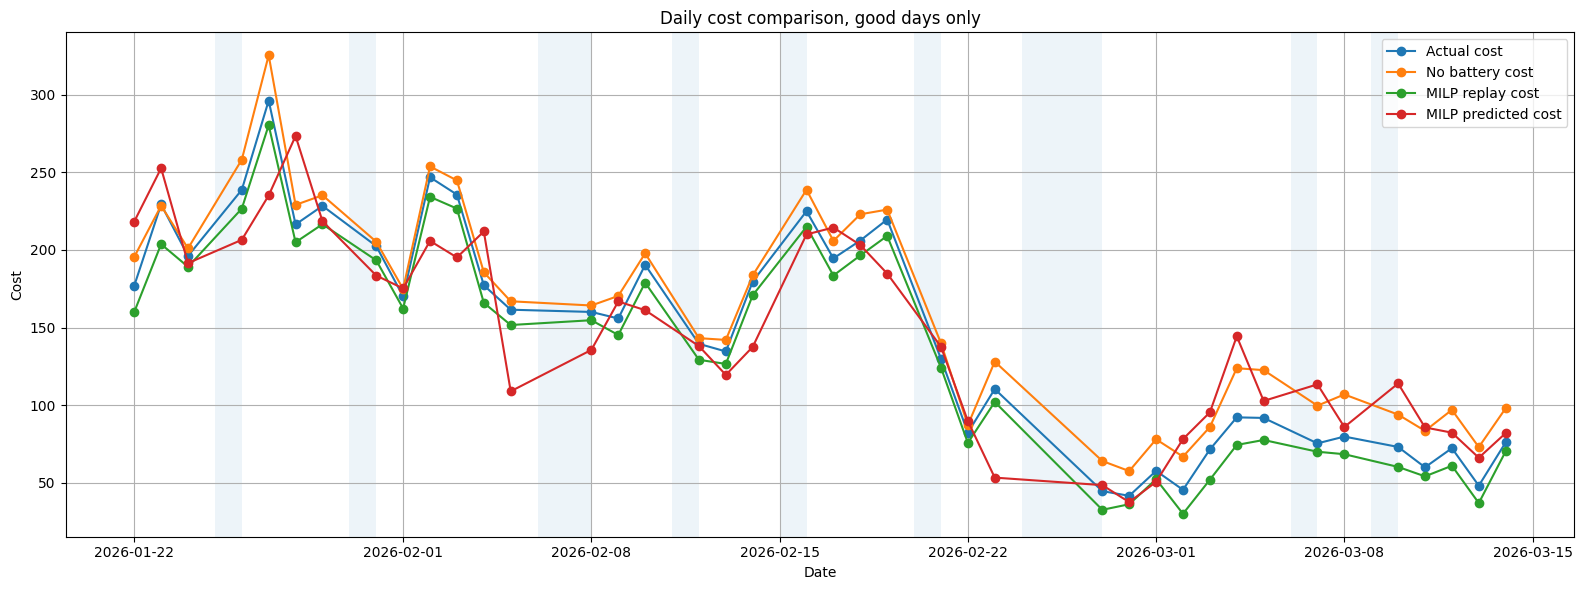

Number of good calculated days: 40


In [56]:
def plot_daily_costs(
    daily: pd.DataFrame,
    start=None,
    end=None,
    all_days_quality: pd.DataFrame | None = None,
):
    df = daily.copy()

    if start is not None:
        start = pd.to_datetime(start)
        df = df[df.index >= start]
    if end is not None:
        end = pd.to_datetime(end)
        df = df[df.index <= end]

    fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(df.index, df["actual_cost"], label="Actual cost", marker="o")
    ax.plot(df.index, df["no_battery_cost"], label="No battery cost", marker="o")
    ax.plot(df.index, df["milp_cost"], label="MILP replay cost", marker="o")

    if "predicted_cost" in df.columns:
        ax.plot(df.index, df["predicted_cost"], label="MILP predicted cost", marker="o")

    if all_days_quality is not None:
        q = all_days_quality.copy()

        if start is not None:
            q = q[q.index >= start]
        if end is not None:
            q = q[q.index <= end]

        if "bad_day" in q.columns:
            for day in q[q["bad_day"]].index:
                ax.axvspan(day, day + pd.Timedelta(days=1), alpha=0.08)

    ax.set_title("Daily cost comparison, good days only")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cost")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

    print(f"Number of good calculated days: {len(df.index)}")


plot_daily_costs(
    daily,
    start=ANALYSIS_START,
    end=ANALYSIS_END,
    all_days_quality=daily_quality,
)


## Optional day-level diagnostic

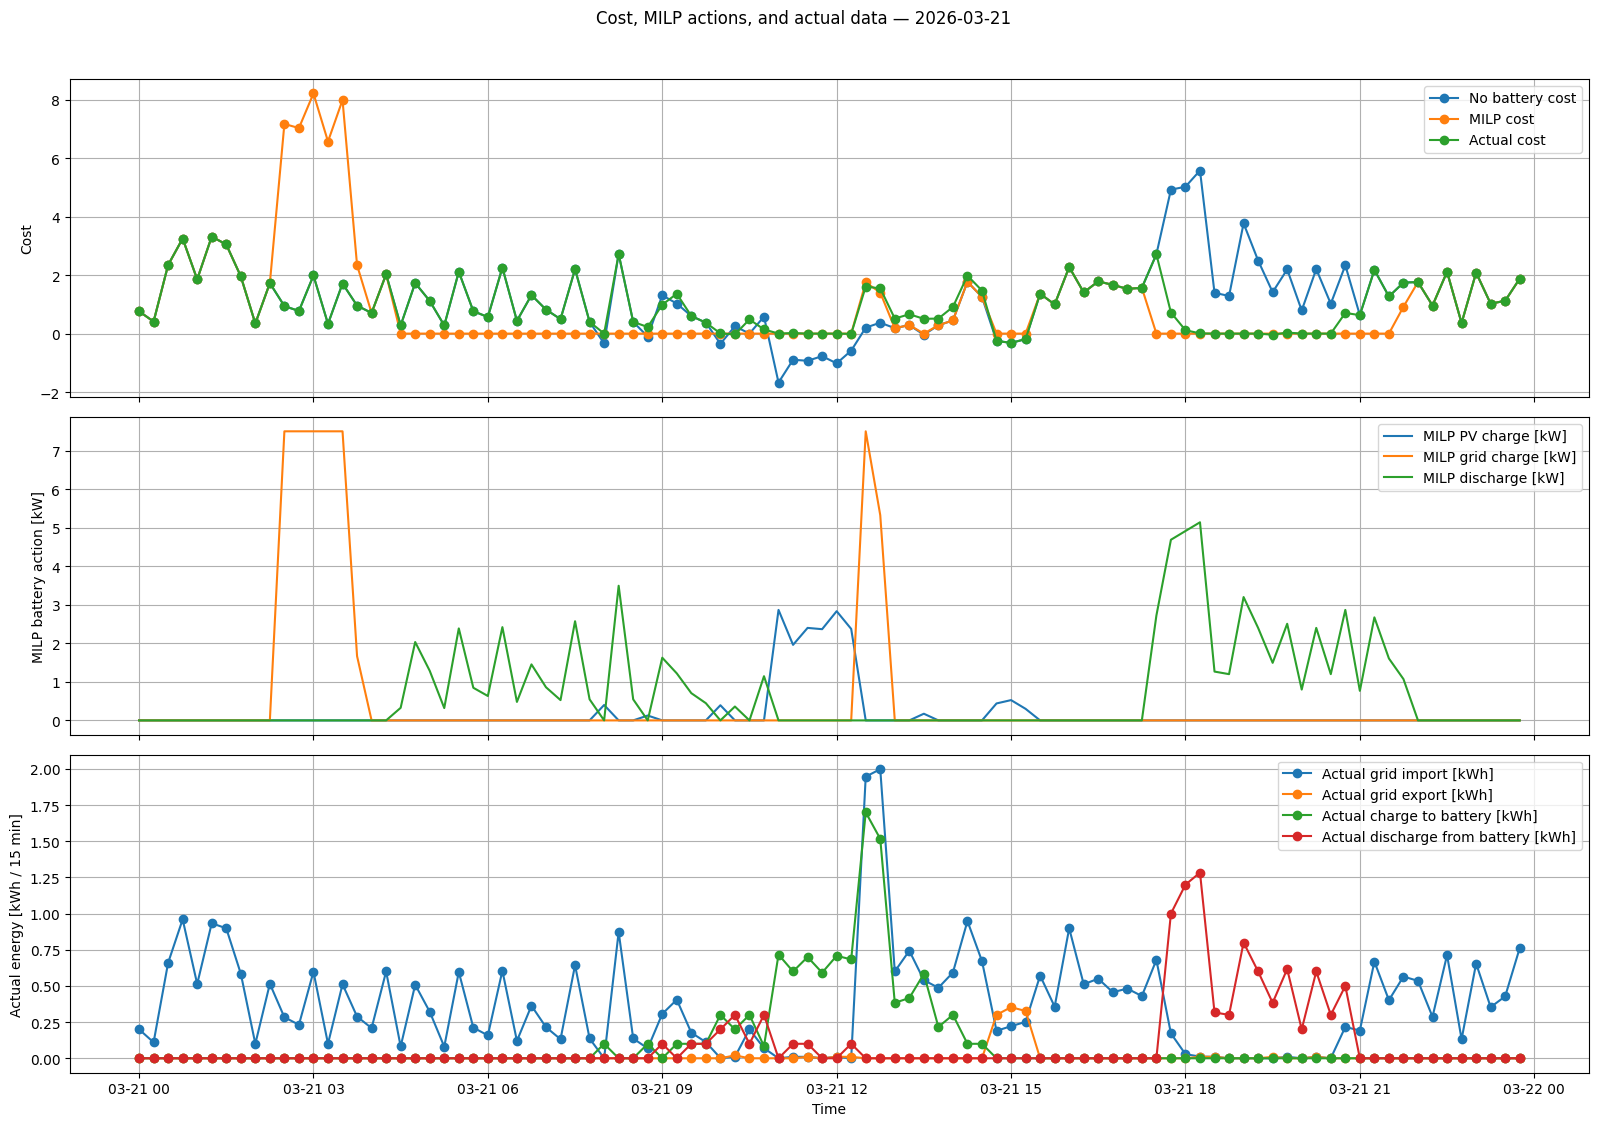

In [19]:
def plot_compare_with_milp_actions(day, nobatt_15, milp_counter_15, actual_cost_15, counter_15):
    day = pd.to_datetime(day).normalize()
    day_end = day + pd.Timedelta(days=1)

    nobatt_day = nobatt_15.loc[
        (nobatt_15.index >= day) &
        (nobatt_15.index < day_end)
    ]

    milp_day = milp_counter_15.loc[
        (milp_counter_15.index >= day) &
        (milp_counter_15.index < day_end)
    ]

    actual_day = actual_cost_15.loc[
        (actual_cost_15.index >= day) &
        (actual_cost_15.index < day_end)
    ]

    counter_day = counter_15.loc[
        (counter_15.index >= day) &
        (counter_15.index < day_end)
    ]

    fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

    # 1) Cost comparison
    axes[0].plot(
        nobatt_day.index,
        nobatt_day["nobatt_cost"],
        label="No battery cost",
        marker="o"
    )
    axes[0].plot(
        milp_day.index,
        milp_day["milp_cost"],
        label="MILP cost",
        marker="o"
    )
    axes[0].plot(
        actual_day.index,
        actual_day["actual_cost"],
        label="Actual cost",
        marker="o"
    )
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_ylabel("Cost")

    # 2) MILP executed battery actions
    axes[1].plot(
        milp_day.index,
        milp_day["milp_exec_pv_charge_kw"],
        label="MILP PV charge [kW]"
    )
    axes[1].plot(
        milp_day.index,
        milp_day["milp_exec_grid_charge_kw"],
        label="MILP grid charge [kW]"
    )
    axes[1].plot(
        milp_day.index,
        milp_day["milp_exec_discharge_kw"],
        label="MILP discharge [kW]"
    )
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_ylabel("MILP battery action [kW]")

    # 3) Actual measured data from counters
    axes[2].plot(
        counter_day.index,
        counter_day["buy_kwh"],
        label="Actual grid import [kWh]",
        marker="o"
    )
    axes[2].plot(
        counter_day.index,
        counter_day["sell_kwh"],
        label="Actual grid export [kWh]",
        marker="o"
    )
    axes[2].plot(
        counter_day.index,
        counter_day["to_bat_kwh"],
        label="Actual charge to battery [kWh]",
        marker="o"
    )
    axes[2].plot(
        counter_day.index,
        counter_day["from_bat_kwh"],
        label="Actual discharge from battery [kWh]",
        marker="o"
    )

    # Optional: show bad/low-coverage intervals if those columns exist
    if "has_counter_coverage" in counter_day.columns:
        bad_coverage = counter_day[~counter_day["has_counter_coverage"]]

        for ts in bad_coverage.index:
            axes[2].axvspan(
                ts,
                ts + pd.Timedelta(minutes=15),
                alpha=0.15,
                color="red"
            )

    axes[2].legend()
    axes[2].grid(True)
    axes[2].set_ylabel("Actual energy [kWh / 15 min]")
    axes[2].set_xlabel("Time")

    fig.suptitle(f"Cost, MILP actions, and actual data — {day.date()}", y=1.02)

    plt.tight_layout()
    plt.show()

plot_compare_with_milp_actions(
    "2026-03-21",
    nobatt_15,
    milp_counter_15,
    actual_cost_15,
    counter_15
)


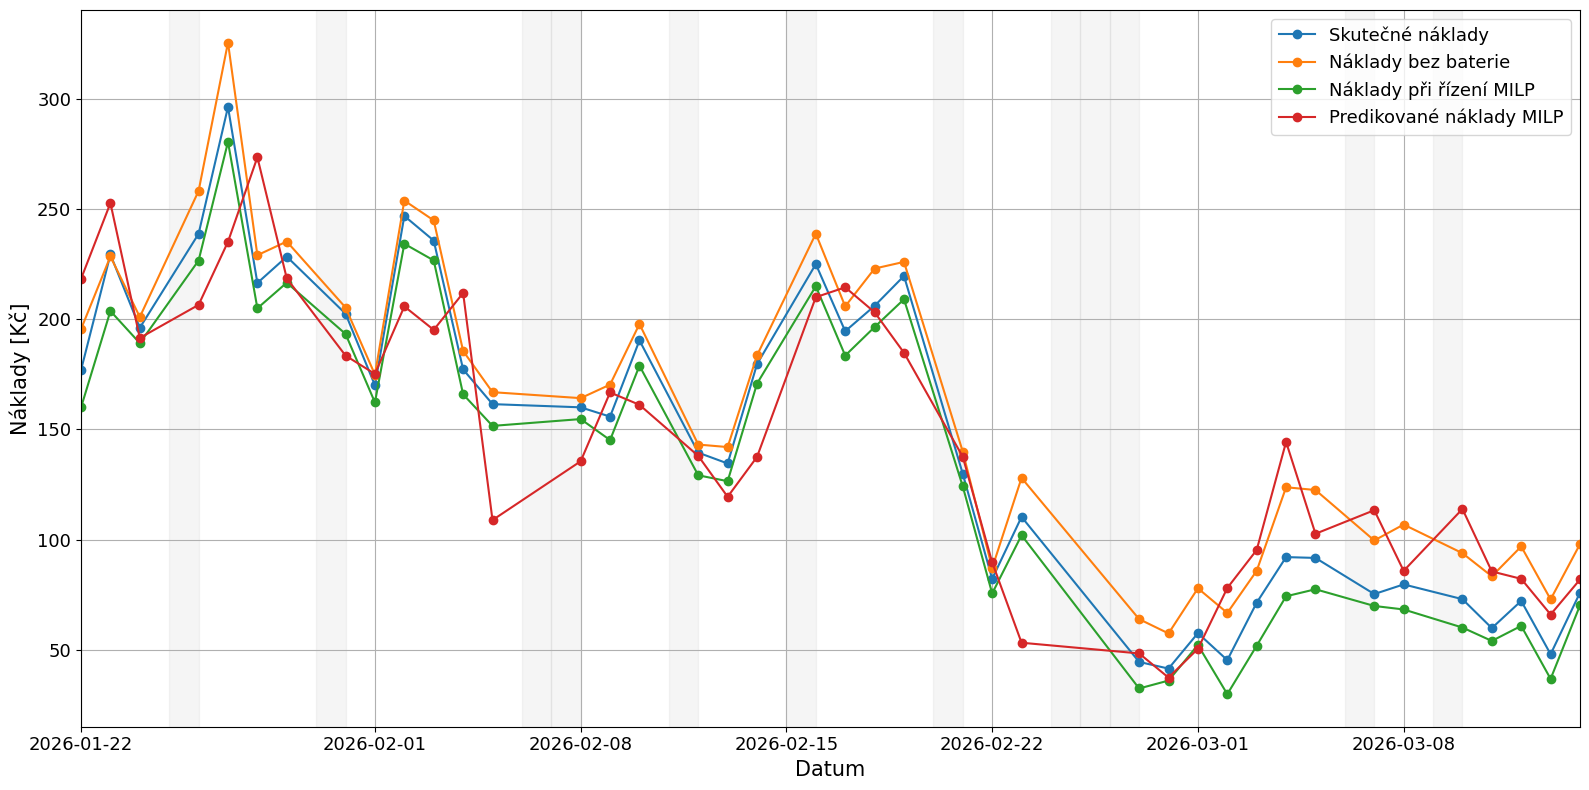

Počet validních dnů zahrnutých do výpočtu: 40


In [55]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_daily_costs_cz(
    daily: pd.DataFrame,
    start=None,
    end=None,
    all_days_quality: pd.DataFrame | None = None,
    show_bad_days_shading: bool = True,
):
    """
    Vykreslí porovnání denních nákladů pouze pro validní dny.

    Parametry
    ----------
    daily : pd.DataFrame
        DataFrame obsahující pouze validní dny.
        Očekávané sloupce:
            - actual_cost
            - no_battery_cost
            - milp_cost
            - predicted_cost (volitelně)

    start : str | pd.Timestamp | None
        Počáteční datum zobrazení.

    end : str | pd.Timestamp | None
        Koncové datum zobrazení.

    all_days_quality : pd.DataFrame | None
        DataFrame s informací o kvalitě všech dnů.
        Očekává se sloupec:
            - bad_day
        Pokud je zadán, mohou být vyřazené dny v grafu šedě zvýrazněny.

    show_bad_days_shading : bool
        Pokud True a je k dispozici all_days_quality, budou v grafu
        vyznačeny vyřazené dny.
    """

    # Kopie dat a seřazení podle indexu
    df = daily.copy().sort_index()

    # Filtrování podle období
    if start is not None:
        start = pd.to_datetime(start)
        df = df[df.index >= start]

    if end is not None:
        end = pd.to_datetime(end)
        df = df[df.index <= end]

    # Kontrola prázdných dat
    if df.empty:
        print("Pro zadané období nejsou k dispozici žádné validní dny.")
        return

    # Vytvoření grafu
    fig, ax = plt.subplots(figsize=(16, 8))

    ax.plot(
        df.index,
        df["actual_cost"],
        label="Skutečné náklady",
        marker="o",
    )

    ax.plot(
        df.index,
        df["no_battery_cost"],
        label="Náklady bez baterie",
        marker="o",
    )

    ax.plot(
        df.index,
        df["milp_cost"],
        label="Náklady při řízení MILP",
        marker="o",
    )

    if "predicted_cost" in df.columns:
        ax.plot(
            df.index,
            df["predicted_cost"],
            label="Predikované náklady MILP",
            marker="o",
        )

    # Zvýraznění vyřazených dnů stejně jako v původním grafu
    if show_bad_days_shading and all_days_quality is not None:
        q = all_days_quality.copy().sort_index()

        if start is not None:
            q = q[q.index >= start]
        if end is not None:
            q = q[q.index <= end]

        if "bad_day" in q.columns:
            for day in q[q["bad_day"]].index:
                ax.axvspan(
                    day,
                    day + pd.Timedelta(days=1),
                    alpha=0.08,
                    color="gray",
                )

    # České popisky
    # ax.set_title(
    #     f"Porovnání denních nákladů pro validní dny ($n = {len(df.index)}$)",
    #     fontsize=18
    # )
    ax.set_xlabel("Datum", fontsize=15)
    ax.set_ylabel("Náklady [Kč]", fontsize=15)
    ax.grid(True)
    ax.legend(fontsize=13)
    ax.set_xlim(
        df.index.min(),
        df.index.max()
    )
    ax.tick_params(axis="both", labelsize=13)
    plt.tight_layout()
    plt.show()

    print(f"Počet validních dnů zahrnutých do výpočtu: {len(df.index)}")
    fig.savefig("porovnani_dennich_nakladu.png", bbox_inches="tight", dpi=300)


# Volání funkce
plot_daily_costs_cz(
    daily,
    start=ANALYSIS_START,
    end=ANALYSIS_END,
    all_days_quality=daily_quality,
    show_bad_days_shading=True,
)